In [22]:
from IPython.display import Markdown, display

with open("description.md", "r") as file:
    md_content = file.read()
display(Markdown(md_content))

# Task 2 - Initial value problem for nonlinear Burgers equation with periodic conditions

**Difficulty:** Easy

## Problem Statement

Solve the nonlinear Burgers equation:
$$u_t + \frac{1}{2}(u^2)_x = 0$$

on the interval $[0,2\pi]$ with periodic boundary conditions and initial condition $u(x,0) = \sin(x)$.

## Requirements

- Use any 1st order scheme
- Solve for time $t = 2$
- Use grid steps $h = 0.02$, $h = 0.01$, and $h = 0.005$
- Estimate error magnitude and order of accuracy from computed values


In [23]:
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go

## 1. Initial Condition
The problem is to solve the Burgers equation on $[0, 2\pi]$ with periodic boundary conditions and initial condition $u(x,0) = \sin(x)$.

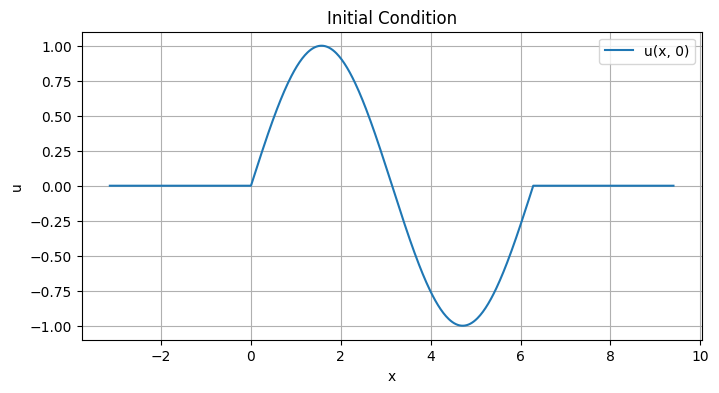

In [24]:
x0 = -np.pi
L = 4 * np.pi
h = 0.02  # Grid step
N = int(np.round(L / h))
dx = L / N
x = np.linspace(x0, x0 + L, N, endpoint=False)


def u0_func(x):
    return np.where((x >= 0) & (x <= 2 * np.pi), np.sin(x), 0.0)


u_init = u0_func(x)

plt.figure(figsize=(8, 4))
plt.plot(x, u_init, label="u(x, 0)")
plt.title("Initial Condition")
plt.xlabel("x")
plt.ylabel("u")
plt.grid(True)
plt.legend()
plt.show()

## 2. First Order Schemes: Upwind and Lax-Friedrichs
We implement the **Upwind** and **Lax-Friedrichs** schemes. Both are first-order accurate.

The flux function for Burgers equation is $f(u) = \frac{1}{2}u^2$.

In [25]:
def flux(u):
    return 0.5 * u**2


def solve_first_order(scheme_name, h, t_end):
    N = int(np.round(L / h))
    dx = L / N
    x = np.linspace(x0, x0 + L, N, endpoint=False)
    u = u0_func(x)

    t = 0
    # CFL condition: dt <= dx / max(|u|). max|u| is 1.
    dt = 0.5 * dx

    while t < t_end:
        if t + dt > t_end:
            dt = t_end - t

        u_ip1 = np.roll(u, -1)  # u_{i+1}
        u_im1 = np.roll(u, 1)  # u_{i-1}

        if scheme_name == "Lax-Friedrichs":
            f_ip1 = flux(u_ip1)
            f_im1 = flux(u_im1)
            u_new = 0.5 * (u_im1 + u_ip1) - 0.5 * (dt / dx) * (f_ip1 - f_im1)

        elif scheme_name == "Upwind":
            # Vectorized Upwind Flux calculation based on the lesson logic
            # F_{i+1/2}
            ul = u
            ur = u_ip1
            F_right = np.where(ul + ur > 0, flux(ul), flux(ur))

            # F_{i-1/2}
            ul = u_im1
            ur = u
            F_left = np.where(ul + ur > 0, flux(ul), flux(ur))

            u_new = u - (dt / dx) * (F_right - F_left)

        u = u_new
        t += dt

    return x, u


# Run simulations
x, u_lf = solve_first_order("Lax-Friedrichs", h, 2.0)
x, u_up = solve_first_order("Upwind", h, 2.0)

## 3. Second Order Scheme: Lax-Wendroff
The **Lax-Wendroff** scheme is second-order accurate ($O(\Delta t^2, \Delta x^2)$). However, it introduces dispersive errors (oscillations) near shocks. To mitigate this, we can add an **artificial viscosity** term.

In [26]:
def solve_lax_wendroff(h, t_end, eps=0.0):
    N = int(np.round(L / h))
    dx = L / N
    x = np.linspace(x0, x0 + L, N, endpoint=False)
    u = u0_func(x)

    t = 0
    dt = 0.5 * dx

    # Store history for animation
    history = [(t, u.copy())]

    while t < t_end:
        if t + dt > t_end:
            dt = t_end - t

        u_ip1 = np.roll(u, -1)
        u_im1 = np.roll(u, 1)

        # Lax-Wendroff Flux
        # F_{i+1/2}
        a_half = 0.5 * (u + u_ip1)
        q = (dt / dx) * a_half**2
        F_right = 0.5 * (flux(u) + flux(u_ip1)) - 0.5 * q * (u_ip1 - u)

        # F_{i-1/2}
        a_half_left = 0.5 * (u_im1 + u)
        q_left = (dt / dx) * a_half_left**2
        F_left = 0.5 * (flux(u_im1) + flux(u)) - 0.5 * q_left * (u - u_im1)

        u_new = u - (dt / dx) * (F_right - F_left)

        # Artificial Viscosity
        if eps > 0:
            # eps * ( (u_{i-1} - u_i) - (u_i - u_{i+1}) )
            visc = eps * ((u_im1 - u) - (u - u_ip1))
            u_new += visc

        u = u_new
        t += dt
        history.append((t, u.copy()))

    return x, u, history


# Run Lax-Wendroff without and with viscosity
x, u_lw, _ = solve_lax_wendroff(h, 2.0, eps=0.0)
x, u_lw_visc, hist_lw_visc = solve_lax_wendroff(h, 2.0, eps=0.1)

## 4. Comparison of Schemas
Here we compare the results of all four simulations at $t=2$.
- **Lax-Friedrichs**: Diffusive (smears the shock).
- **Upwind**: Less diffusive than LF, but still 1st order.
- **Lax-Wendroff**: Oscillatory near the shock (dispersive errors).
- **Lax-Wendroff + Viscosity**: Oscillations are dampened.

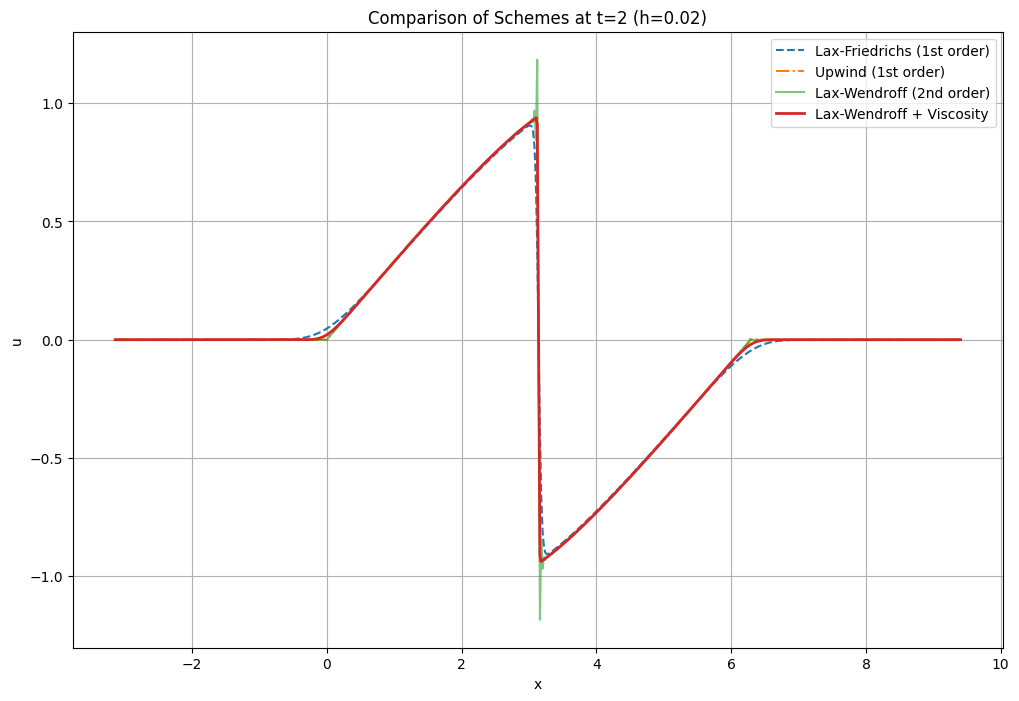

In [27]:
plt.figure(figsize=(12, 8))
plt.plot(x, u_lf, label="Lax-Friedrichs (1st order)", linestyle="--")
plt.plot(x, u_up, label="Upwind (1st order)", linestyle="-.")
plt.plot(x, u_lw, label="Lax-Wendroff (2nd order)", alpha=0.6)
plt.plot(x, u_lw_visc, label="Lax-Wendroff + Viscosity", linewidth=2)

plt.title(f"Comparison of Schemes at t=2 (h={h})")
plt.xlabel("x")
plt.ylabel("u")
plt.grid(True)
plt.legend()
plt.show()

## 5. Animation
We use Plotly to animate the evolution of the solution using the **Lax-Wendroff scheme with artificial viscosity**.

In [30]:
# Downsample history for smoother animation (e.g., every 5th frame)
step = 5
frames = []
for i in range(0, len(hist_lw_visc), step):
    t_val, u_val = hist_lw_visc[i]
    frames.append(
        go.Frame(data=[go.Scatter(x=x, y=u_val, mode="lines")], name=f"frame{i}")
    )

fig = go.Figure(
    data=[go.Scatter(x=x, y=hist_lw_visc[0][1], mode="lines", name="u(x,t)")],
    layout=go.Layout(
        title="Burgers Equation Evolution (Lax-Wendroff + Viscosity)",
        xaxis=dict(range=[x0, x0 + L], title="x"),
        yaxis=dict(range=[-1.5, 1.5], title="u"),
        updatemenus=[
            dict(
                type="buttons",
                buttons=[
                    dict(
                        label="Play",
                        method="animate",
                        args=[
                            None,
                            dict(
                                frame=dict(duration=30, redraw=True), fromcurrent=True
                            ),
                        ],
                    )
                ],
            )
        ],
    ),
    frames=frames,
)

fig.show()